Input: i love you
Output: t aime aime


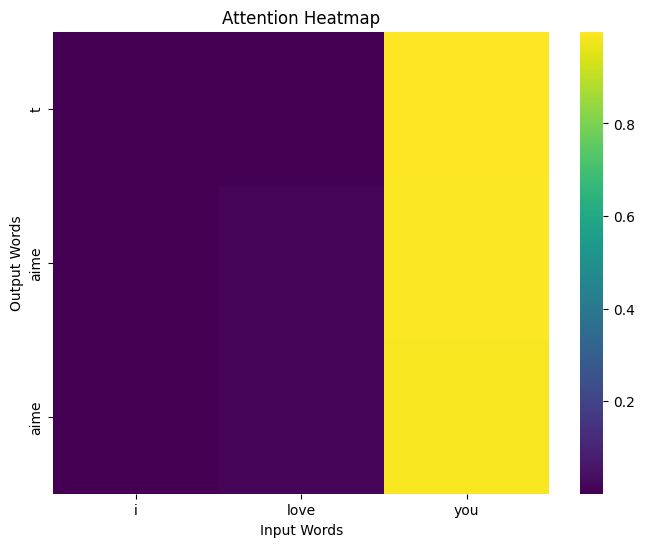

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, RepeatVector, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 1. Data
input_texts = ["i love you", "i hate you", "hello", "how are you"]
target_texts = ["je t aime", "je te deteste", "bonjour", "comment ca va"]

# 🔹 2. Tokenization
input_tokenizer = Tokenizer()
input_tokenizer.fit_on_texts(input_texts)
input_seq = input_tokenizer.texts_to_sequences(input_texts)
max_input_len = max(len(seq) for seq in input_seq)
input_seq = pad_sequences(input_seq, maxlen=max_input_len, padding='post')

target_tokenizer = Tokenizer(filters='')
target_tokenizer.fit_on_texts(target_texts)
target_seq = target_tokenizer.texts_to_sequences(target_texts)
max_target_len = max(len(seq) for seq in target_seq)
target_seq = pad_sequences(target_seq, maxlen=max_target_len, padding='post')

decoder_input = target_seq[:, :-1]
decoder_output = target_seq[:, 1:]

# 🔹 3. Attention Layer
class Attention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(Attention, self).__init__()
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V = Dense(1)

    def call(self, decoder_hidden, encoder_outputs):
        hidden = tf.expand_dims(decoder_hidden, 1)

        score = self.V(
            tf.nn.tanh(
                self.W1(encoder_outputs) + self.W2(hidden)
            )
        )

        attention_weights = tf.nn.softmax(score, axis=1)

        context = attention_weights * encoder_outputs
        context = tf.reduce_sum(context, axis=1)

        return context, tf.squeeze(attention_weights, axis=-1)

# 🔹 4. Model
vocab_in = len(input_tokenizer.word_index) + 1
vocab_out = len(target_tokenizer.word_index) + 1
latent_dim = 64

# Encoder
encoder_inputs = tf.keras.Input(shape=(max_input_len,))
enc_emb_layer = Embedding(vocab_in, latent_dim)
enc_emb = enc_emb_layer(encoder_inputs)

encoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

# Decoder
decoder_inputs = tf.keras.Input(shape=(max_target_len - 1,))
dec_emb_layer = Embedding(vocab_out, latent_dim)
dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

# Attention
attention = Attention(latent_dim)
context_vector, attention_weights = attention(state_h, encoder_outputs)

# Repeat context
context_vector = RepeatVector(max_target_len - 1)(context_vector)

# Combine
decoder_combined = Concatenate(axis=-1)([decoder_outputs, context_vector])

# Output
output_dense = Dense(vocab_out, activation='softmax')
outputs = output_dense(decoder_combined)

# Model compile
model = Model([encoder_inputs, decoder_inputs], outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# 🔹 5. Train
model.fit(
    [input_seq, decoder_input],
    np.expand_dims(decoder_output, -1),
    epochs=200,
    verbose=0
)

# 🔹 6. Encoder model for inference
encoder_model = Model(encoder_inputs, [encoder_outputs, state_h, state_c])

# 🔹 7. Prediction with Attention
def predict_with_attention(input_sentence):
    seq = input_tokenizer.texts_to_sequences([input_sentence])
    seq = pad_sequences(seq, maxlen=max_input_len, padding='post')

    enc_out, h, c = encoder_model.predict(seq, verbose=0)

    target_seq = np.zeros((1, 1))
    attention_plot = []
    decoded_sentence = []

    for _ in range(max_target_len):
        dec_emb_step = dec_emb_layer(target_seq)
        dec_out, h, c = decoder_lstm(dec_emb_step, initial_state=[h, c])

        context, attn = attention(h, enc_out)
        attention_plot.append(attn[0].numpy())

        context = tf.expand_dims(context, 1)
        combined = tf.concat([dec_out, context], axis=-1)

        preds = output_dense(combined)
        token = np.argmax(preds[0, -1, :])

        if token == 0:
            break

        word = target_tokenizer.index_word.get(token, '')
        decoded_sentence.append(word)

        target_seq = np.array([[token]])

    return input_sentence, " ".join(decoded_sentence), np.array(attention_plot)

# 🔹 8. Heatmap
def plot_attention(input_sentence, output_sentence, attention):
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        attention,
        xticklabels=input_sentence.split(),
        yticklabels=output_sentence.split(),
        cmap="viridis"
    )
    plt.xlabel("Input Words")
    plt.ylabel("Output Words")
    plt.title("Attention Heatmap")
    plt.show()

# 🔹 9. Run
inp, out, attn = predict_with_attention("i love you")

print("Input:", inp)
print("Output:", out)

plot_attention(inp, out, attn)